In [1]:
import rich
import logging
import glob

import matplotlib.pyplot as plt
import time
import os
import awkward as ak
import numpy as np
import pandas as pd
from lgdo import lh5
from legendmeta import LegendMetadata
from dbetto import Props
from pygama.pargen.AoE_cal import *
from pygama.pargen.AoE_cal import CalAoE, Pol1, SigmaFit, aoe_peak
from pygama.pargen.data_cleaning import get_tcm_pulser_ids
from pygama.pargen.utils import load_data
from tqdm import tqdm

%matplotlib inline

logging.basicConfig(level=logging.INFO)
logging.getLogger('numba').setLevel(logging.INFO)
logging.getLogger('parse').setLevel(logging.INFO)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.12/site-packages/tornado

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



# Path to data


In [2]:
data_path = "/global/cfs/cdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/latest"
config = Props.read_from(os.path.join(data_path, "config.json"), subst_pathvar=True)["setups"]["l200"]["paths"]
meta  = LegendMetadata(config["metadata"])
chmap = meta.channelmap(meta.dataprod.runinfo.p03.r000.phy.start_key)

In [3]:
# Qui posso veedere quale è la versione giusta di hit (o altro che mis erve)
# a cui punta il mio file di config ovvero, in questo caso, la versione v2..1.5 e dalla quale posso caricare per gli studi dei QC

config['tier_pet']

'/global/cfs/cdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/latest/generated/tier/pet'

# Get files

In [4]:
# PRENDO I DATI DI FISICA E NON DI CALIBRAZIONE f"{config["tier_psp"]}/cal/p03/r000/*.lh5" ---> f"{config["tier_psp"]}/phy/p03/r000/*.lh5"
pet_files = sorted(glob.glob(f"{config["tier_pet"]}/phy/l200-p03-r000-phy-tier_pet.lh5"))
psp_files = sorted(glob.glob(f"{config["tier_psp"]}/phy/p03/r000/*.lh5")) #access exsiting DSP-processed data such as the energy for partitions
tcm_files = sorted(glob.glob(f"{config["tier_tcm"]}/phy/p03/r000/*.lh5"))  # --> solo per il pulse
raw_files = sorted(glob.glob(f"{config["tier_raw"]}/phy/p03/r000/*.lh5"))

In [5]:
channel = f'ch{chmap.V02160A.daq.rawid}'
detector = "V02160A"
channel

'ch1104000'

In [6]:
# The cal_dict we can pull from a hit_results file generated by the dataflow

cal_file = f"{config["par_pht"]}/cal/p03/r000/l200-p03-r000-cal-20230311T235840Z-par_pht.json"
cal_dict = Props.read_from(cal_file)[channel]["pars"]["operations"]



# Functions

In [7]:
def build_geometry_data(detector_type,   # nome detector
                        channels_rawid,  # tutti i canali
                        psp_files,       # directory --> fissa
                        trigger_data,    # directory --> fissa
                        coincident_data, # directory --> fissa
                        params,          # parametri di DSP che mi voglio salvare
                        classifier_params, # parametri di DSP di cui volgio costruire il classifier
                        outdir="Parquet data r000", # directory dove salvo i dati di parquet
                        force=False):

    os.makedirs(outdir, exist_ok=True)

    outpath = f"{outdir}/data_{detector_type}_phy_ALL.parquet"

    if os.path.exists(outpath) and not force:
        print(f"Loading cached: {outpath}")
        return pd.read_parquet(outpath)

    dfs = []
    start = time.time()

    for channel in tqdm(channels_rawid[detector_type]):

        # --------------------------
        # CAL FILE DIPENDE DAL CANALE
        # --------------------------
        cal_dict = Props.read_from(cal_file)[channel]["pars"]["operations"]

        df = load_data(files=psp_files,
            lh5_path=f"{channel}/dsp",
            cal_dict=cal_dict,
            params=params,
            return_selection_mask=False,
        ).copy()

        # --------------------------
        # FLAGS GLOBALI
        # --------------------------
        df["forced_trigger"] = ak.to_numpy(trigger_data["is_forced"])
        df["is_pulser"] = coincident_data["puls"]
        df["is_muon"] = coincident_data["muon_offline"]
        df["is_HPGe"] = coincident_data["geds"]

        df["is_discharge"] = df["t_sat_lo"] > 0

        df["is_below_500keV"] = (
            (df["cuspEmax_ctc_cal"] > 25) &
            (df["cuspEmax_ctc_cal"] < 500)
        )

        # --------------------------
        # CLASSIFIERS
        # --------------------------
        for param in classifier_params:
            df = classifier_fun(df, cal_dict, param)

        dfs.append(df)

    data = pd.concat(dfs, ignore_index=True)

    print(f"Took {time.time() - start:.2f} s")

    data.to_parquet(outpath, index=False)
    print(f"Saved: {outpath}")

    return data

In [8]:
def classifier_fun(data, cal_dict, param):
    a_class = cal_dict[f"is_valid_{param}_classifier"]['parameters']['a']
    b_class = cal_dict[f"is_valid_{param}_classifier"]['parameters']['b']
    
    classifier = (data[f"{param}"] - a_class) / b_class

    data[f"classifier_{param}"] = classifier

    return data

In [9]:
def classifier_plot(data, param, bins = 250):
    # flags
    m_dis = ~data["is_discharge"]  # no scarica
    m_pulser = data["is_pulser"]   # si PULSER
    m_ft = data["forced_trigger"]  # si FORCED TRIGGER
    m_lowE = data["is_below_500keV"] # energie tra 25 e 500 keV
    m_coinc = data["is_HPGe"]&~data["is_muon"]
    
    # data
    classifier = data[f"classifier_{param}"]
    plt.figure(figsize = (8,6))
    plt.hist(classifier[m_dis], bins = bins, range = (-5, 15),  histtype = 'step', label = 'All')
    plt.hist(classifier[m_dis & m_pulser], bins = bins, range = (-5, 15),  histtype = 'step', label = 'is_pulser')
    plt.hist(classifier[m_dis & m_ft], bins = bins, range = (-5, 15),  histtype = 'step', label = 'is_forced_trigger')
    plt.hist(classifier[m_dis & ~m_ft & ~m_pulser & m_lowE], bins = bins, range = (-5, 15),  histtype = 'step', label = '~PL & ~FT & <500 keV')
    
    plt.vlines(-5, 0, 1e5, ls = '--', color = 'grey' )
    plt.vlines(5, 0, 1e5, ls = '--', color = 'grey', label = 'Classifier CUT' )
    plt.ylim(1, 1e5)
    plt.xlim(-6, 6)
    plt.legend(loc = 'upper right')
    plt.ylabel(f"Counts")
    plt.xlabel(f"Classifier {param}")
    plt.axvspan(-25, -5, color = 'grey', alpha=0.15)
    plt.axvspan(5,25, color = 'grey', alpha=0.15)
    #plt.title(f"{detector}")
    plt.yscale('log')
    plt.savefig(f"{param}_class.svg", dpi = 600)
    
    return

In [10]:
def all_plots(data, params,cmax = 6, title = "detector type"):
    fig, axes = plt.subplots(1, len(params), figsize=(18,5),  sharey=True)

    if len(params) == 1:
        axes = [axes]
    
    for ax, par in zip(axes, params):
    
        classifier = data[f"classifier_{par}"]
    
        m_all = ~data["is_discharge"]
        m_pl = m_all & data["is_pulser"]
        m_ft = m_all & data["forced_trigger"]
        m_clean = m_all & ~data["forced_trigger"] & ~data["is_pulser"] & data["is_below_500keV"]
    
        cmin = -6
        #cmax = 50
        bins = 250
    
        ax.hist(classifier[m_all], bins=bins, range=(cmin, cmax), histtype='step', label='All')
        ax.hist(classifier[m_pl], bins=bins, range=(cmin, cmax), histtype='step', label='PL')
        ax.hist(classifier[m_ft], bins=bins, range=(cmin, cmax), histtype='step', label='FT')
        ax.hist(classifier[m_clean], bins=bins, range=(cmin, cmax), histtype='step', label='~PL & ~FT & <500 keV')
    
    
        ax.axvspan(-25, -5, color = 'grey', alpha=0.15)
        ax.axvspan(5,cmax, color = 'grey', alpha=0.15)
        ax.vlines(-5, 0, 1e6, ls = '--', color = 'grey' )
        ax.vlines(5, 0, 1e6, ls = '--', color = 'grey', label = 'Classifier CUT' )
        ax.set_title(par)
        ax.set_ylabel('Counts')
        ax.set_xlabel(f'Classifier')
        ax.set_yscale('log')
        ax.set_xlim(cmin, cmax)
        ax.set_ylim(1, 1e6)
        ax.legend(loc = 'upper right')

    fig.suptitle(title)
    plt.tight_layout()

    return

In [11]:
def energy_spectrum_cut_plot(data, classifier_par):
    ene = data['cuspEmax_ctc_cal']
    
    m_discharge = ~data["is_discharge"]
    m_pulser = data["is_pulser"]
    m_ft = data["forced_trigger"]
    m_lowE = data["is_below_500keV"]
    m_fix = data["is_HPGe"]&~data["is_muon"]
    m_classifier = data[f"is_valid_{cldataassifier_par}"]

    
    CUT = len(ene[m_discharge & ~m_pulser & ~m_ft & m_fix & ~m_classifier]) * 100/ len(ene[m_discharge & ~m_pulser & ~m_ft & m_fix])
    PASS = len(ene[m_discharge & ~m_pulser & ~m_ft & m_fix & m_classifier]) * 100/ len(ene[m_discharge & ~m_pulser & ~m_ft & m_fix])
    
    emin = -1000
    emax = 6000
    bins = int((emax-emin)/10)
    
    
    plt.figure(figsize = (10,3))
    plt.hist(ene[m_discharge & ~m_pulser & ~m_ft & m_fix], 
             bins = bins, 
             range=(emin, emax), 
             histtype = 'step',
             color = 'gray',
             label = 'All'
            )
    
    plt.hist(ene[m_discharge & ~m_pulser & ~m_ft & m_fix & m_classifier], 
             bins = bins, 
             range=(emin, emax), 
             histtype = 'step',
             color = 'deepskyblue',
             label = f'is_valid_{classifier_par}, PASS={PASS:.3f}%'
            )
    
    plt.hist(ene[m_discharge & ~m_pulser & ~m_ft & m_fix & ~m_classifier], 
             bins = bins, 
             range=(emin, emax), 
             histtype = 'step',
             color = 'brown',
             label = f'~is_valid_{classifier_par}, CUT={CUT:.3f}%'
            )
    
    plt.legend(loc = 'upper right')
    plt.xlabel('Energy [keV]')
    plt.ylabel('Counts / 10 keV')
    plt.title(f'{classifier_par} cut')
    plt.xlim(emin, emax)
    plt.yscale('log')

    

# 1 channel

In [12]:
params = [ 't_sat_lo',
        "bl_slope",
        "bl_slope_rms",
        "tail_rms",
        "cuspEmax_ctc_cal",
        "is_valid_bl_slope",
        "is_valid_bl_slope_rms",
        "is_valid_tail_rms",
        "is_valid_cal"
    ]


In [13]:
# qui mi posso salvare i paramteri di DSP (che ho scelto e definito in config) per lo specfico canale e per tutti gli eventi registrati
data = load_data(
        files = psp_files,   # da qui prenidmao i dati di dsp già processati 
        lh5_path = f"{channel}/dsp",  # prendo i risultati del dsp per il canale /detcetor specifico
        cal_dict = Props.read_from(cal_file)[channel]["pars"]["operations"],  # lo prendiamo da par_pht
        params=params,
        return_selection_mask=False,)

In [14]:
data

,bl_slope,bl_slope_rms,cuspEmax,cuspEmax_ctc,cuspEmax_ctc_cal,is_valid_bl_slope,is_valid_bl_slope_rms,is_valid_cal,is_valid_tail,is_valid_tail_rms,t_sat_lo,tail_rms
0,0.016286,12.670416,0.320338,NaN,NaN,True,True,False,True,True,0.0,12.228429
1,0.017787,12.584935,4.296205,4.296067,0.035374,True,True,False,True,True,0.0,12.305633
2,-0.004746,12.783596,2.403704,2.403815,-0.257466,True,True,False,True,True,0.0,11.983953
3,0.019171,12.077505,1.586369,1.583160,-0.384468,True,True,False,True,True,0.0,11.961715
4,0.004323,12.946972,4.474205,4.473058,0.062765,True,True,False,True,True,0.0,12.677612
...,...,...,...,...,...,...,...,...,...,...,...,...
214041,-0.024594,11.275720,-0.864503,-0.861656,-0.762822,True,True,False,True,True,0.0,11.801318
214042,-0.011811,12.153982,3.751267,3.749321,-0.049239,True,True,False,True,True,0.0,12.301326
214043,-0.004945,11.519229,5.946424,5.940003,0.289785,True,True,True,True,True,0.0,11.827173
214044,-0.020248,11.674230,4.030265,4.021709,-0.007085,True,True,True,True,True,0.0,11.793462


In [15]:
# trigger
trigger_data = lh5.read_as("/evt/trigger", pet_files, library="ak")
data["forced_trigger"] = ak.to_numpy(trigger_data['is_forced'])

# pulsesr and coincidences 
coincident_data = lh5.read_as("/evt/coincident", pet_files, library="ak")
data["is_pulser"] = coincident_data['puls']  # no pulser events
data["is_muon"] = coincident_data['muon_offline']  # no muons
data["is_HPGe"] = coincident_data['geds']  # only events with an HPGe signal

# energy selection
mask_lowe = (data["cuspEmax_ctc_cal"] > 25) & (data["cuspEmax_ctc_cal"] < 500)
data["is_below_500keV"] = mask_lowe

### Discharge

mask_discharge = data['t_sat_lo']>0
data["is_discharge"] = mask_discharge

In [16]:
params = ["bl_slope", 
          "bl_slope_rms",
         "tail_rms"]


In [18]:
for p in params:
     classifier_fun(data, cal_dict, p)

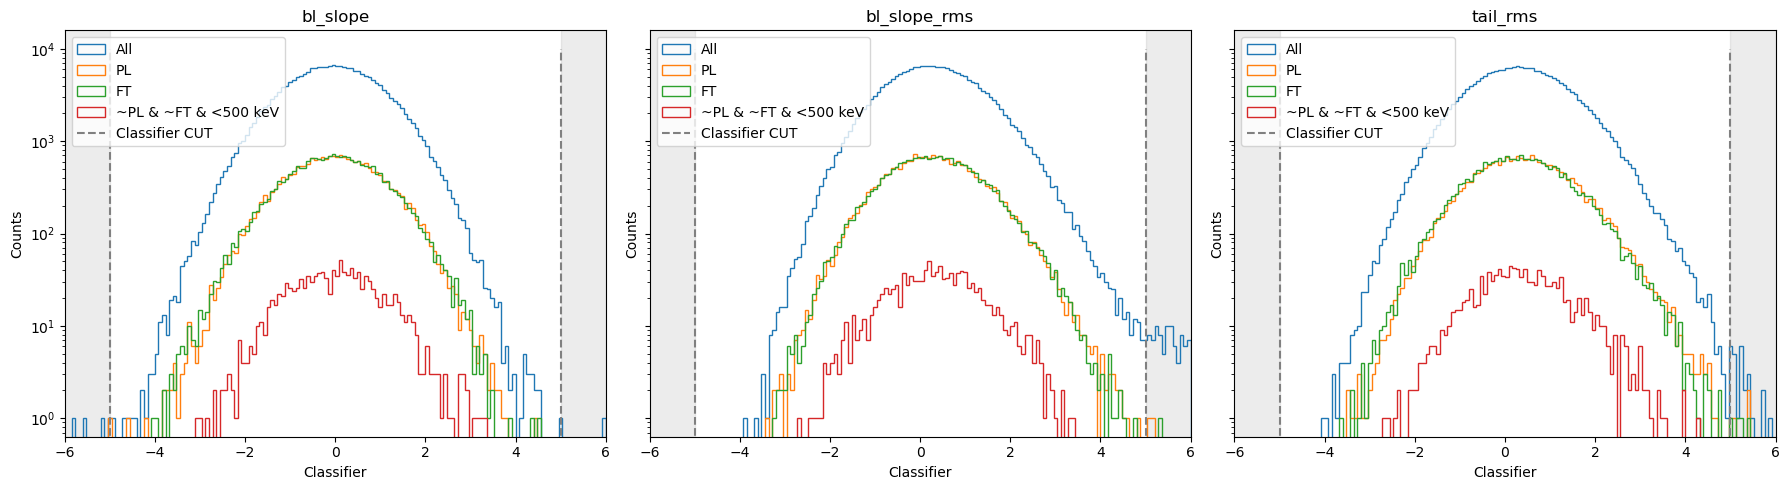

In [19]:
fig, axes = plt.subplots(1, len(params), figsize=(18,5), sharey=True)

if len(params) == 1:
    axes = [axes]

for ax, par in zip(axes, params):

    classifier = data[f"classifier_{par}"]

    m_all = ~data["is_discharge"]
    m_pl = m_all & data["is_pulser"]
    m_ft = m_all & data["forced_trigger"]
    m_clean = m_all & ~data["forced_trigger"] & ~data["is_pulser"] & data["is_below_500keV"]

    cmin = -6
    cmax = 6
    bins = 150

    ax.hist(classifier[m_all], bins=bins, range=(cmin, cmax), histtype='step', label='All')
    ax.hist(classifier[m_pl], bins=bins, range=(cmin, cmax), histtype='step', label='PL')
    ax.hist(classifier[m_ft], bins=bins, range=(cmin, cmax), histtype='step', label='FT')
    ax.hist(classifier[m_clean], bins=bins, range=(cmin, cmax), histtype='step', label='~PL & ~FT & <500 keV')


    ax.axvspan(-25, -5, color = 'grey', alpha=0.15)
    ax.axvspan(5,cmax, color = 'grey', alpha=0.15)
    ax.vlines(-5, 0, 1e4, ls = '--', color = 'grey' )
    ax.vlines(5, 0, 1e4, ls = '--', color = 'grey', label = 'Classifier CUT' )
    ax.set_title(par)
    ax.set_ylabel('Counts')
    ax.set_xlabel(f'Classifier')
    ax.set_yscale('log')
    ax.set_xlim(cmin, cmax)
    ax.legend(loc = 'upper left')

plt.tight_layout()

# ALL detectors

In [95]:
cal = Props.read_from(cal_file)

In [139]:
# tra tutti i detector che ci sono prendo solo quelli con lo stato di 
# usability = 'on' oppure 'ac'
# processability = True

chmap = meta.channelmap(meta.dataprod.runinfo.p03.r000.phy.start_key)
geds = chmap.group("system").geds

chmap_ak = ak.Array(geds.values())

rawids = ak.to_numpy(chmap_ak.daq.rawid)
names = ak.to_numpy(chmap_ak["name"]).astype(str)

# Leggi la usability di ciascun detector
usability = np.array([
    getattr(det.analysis, "usability", None)
    for det in geds.values()
])

# Tieni tutto tranne i detector con usability == "off"
mask_not_off = (usability != "off")

# (Opzionale) Controlla quali stati sono presenti
print("Usability presenti:", np.unique(usability))

# Maschere per tipo di detector, escludendo solo gli "off"
masks_name = {
    "ICPC": np.char.startswith(names, "V") & mask_not_off,
    "BEGe": np.char.startswith(names, "B") & mask_not_off,
    "Coax": np.char.startswith(names, "C") & mask_not_off,
    "PPC":  np.char.startswith(names, "P") & mask_not_off,
}
det_names = ["ICPC", "BEGe", "Coax", "PPC"]

Usability presenti: ['ac' 'off' 'on']


In [135]:
channels_rawid = {
    det_type: [f"ch{rid}" for rid in rawids[mask]]
    for det_type, mask in masks_name.items()
}

channels_names = {
    det_type: names[mask].tolist()
    for det_type, mask in masks_name.items()
}

print("\nExcluded channels (usability='off' OR processable=False):")

for ch, det in geds.items():

    usability = getattr(det.analysis, "usability", None)
    processable = getattr(det.analysis, "processable", None)

    if (usability == "off") or (processable is False):

        print(
            f"channel={ch:3d} | "
            f"rawid=ch{det.daq.rawid:5d} | "
            f"name={det.name:20s} | "
            f"usability={usability} | "
            f"processable={processable}"
        )

# Riassunto
for det_type in channels_names:
    print(f"\n{det_type}: {len(channels_names[det_type])} detector")
    print(channels_names[det_type])


Excluded channels (usability='off' OR processable=False):
channel= 17 | rawid=ch1108804 | name=V07298B              | usability=off | processable=False
channel= 21 | rawid=ch1110405 | name=P00665A              | usability=off | processable=False
channel= 34 | rawid=ch1115200 | name=V01386A              | usability=off | processable=False
channel= 35 | rawid=ch1115201 | name=V01403A              | usability=off | processable=False
channel= 36 | rawid=ch1115202 | name=V01404A              | usability=off | processable=False
channel= 64 | rawid=ch1080002 | name=B00091D              | usability=off | processable=False
channel= 65 | rawid=ch1080003 | name=P00537A              | usability=off | processable=False
channel= 74 | rawid=ch1083200 | name=B00091B              | usability=off | processable=False
channel= 91 | rawid=ch1088000 | name=P00538B              | usability=off | processable=False
channel= 95 | rawid=ch1088004 | name=P00661A              | usability=off | processable=False
c

In [146]:
cal_file = f"{config["par_pht"]}/cal/p03/r000/l200-p03-r000-cal-20230311T235840Z-par_pht.json"
trigger_data = lh5.read_as("/evt/trigger", pet_files, library="ak")
coincident_data = lh5.read_as("/evt/coincident", pet_files, library="ak")

In [191]:
params_class = [ 't_sat_lo',
        "bl_slope",
        "bl_slope_rms",
        "tail_rms",
        "cuspEmax_ctc_cal",
        "is_valid_bl_slope",
        "is_valid_bl_slope_rms",
        "is_valid_tail_rms",
        "is_valid_cal"
    ]
params = ['bl_slope', 'bl_slope_rms', 'tail_rms']

In [190]:
data_ICPC = build_geometry_data(
    detector_type="ICPC",
    channels_rawid=channels_rawid,  # override
    psp_files=psp_files,
    trigger_data=trigger_data,
    coincident_data=coincident_data,
    params=params_class,
    classifier_params=params
)

Loading cached: Parquet data new/data_ICPC_phy_ALL.parquet


In [192]:
data_BEGe = build_geometry_data(
    detector_type="BEGe",
    channels_rawid=channels_rawid,  # override
    psp_files=psp_files,
    trigger_data=trigger_data,
    coincident_data=coincident_data,
    params=params_class,
    classifier_params=params
)

100%|██████████| 26/26 [05:21<00:00, 12.37s/it]


Took 322.04 s
Saved: Parquet data new/data_BEGe_phy_ALL.parquet


In [193]:
data_PPC = build_geometry_data(
    detector_type="PPC",
    channels_rawid=channels_rawid,  # override
    psp_files=psp_files,
    trigger_data=trigger_data,
    coincident_data=coincident_data,
    params=params_class,
    classifier_params=params
)

100%|██████████| 20/20 [03:47<00:00, 11.35s/it]


Took 227.22 s
Saved: Parquet data new/data_PPC_phy_ALL.parquet


In [195]:
data_COAX = build_geometry_data(
    detector_type="Coax",
    channels_rawid=channels_rawid,  # override
    psp_files=psp_files,
    trigger_data=trigger_data,
    coincident_data=coincident_data,
    params=params_class,
    classifier_params=params
)

100%|██████████| 6/6 [01:06<00:00, 11.11s/it]


Took 66.66 s
Saved: Parquet data new/data_Coax_phy_ALL.parquet


# Plots

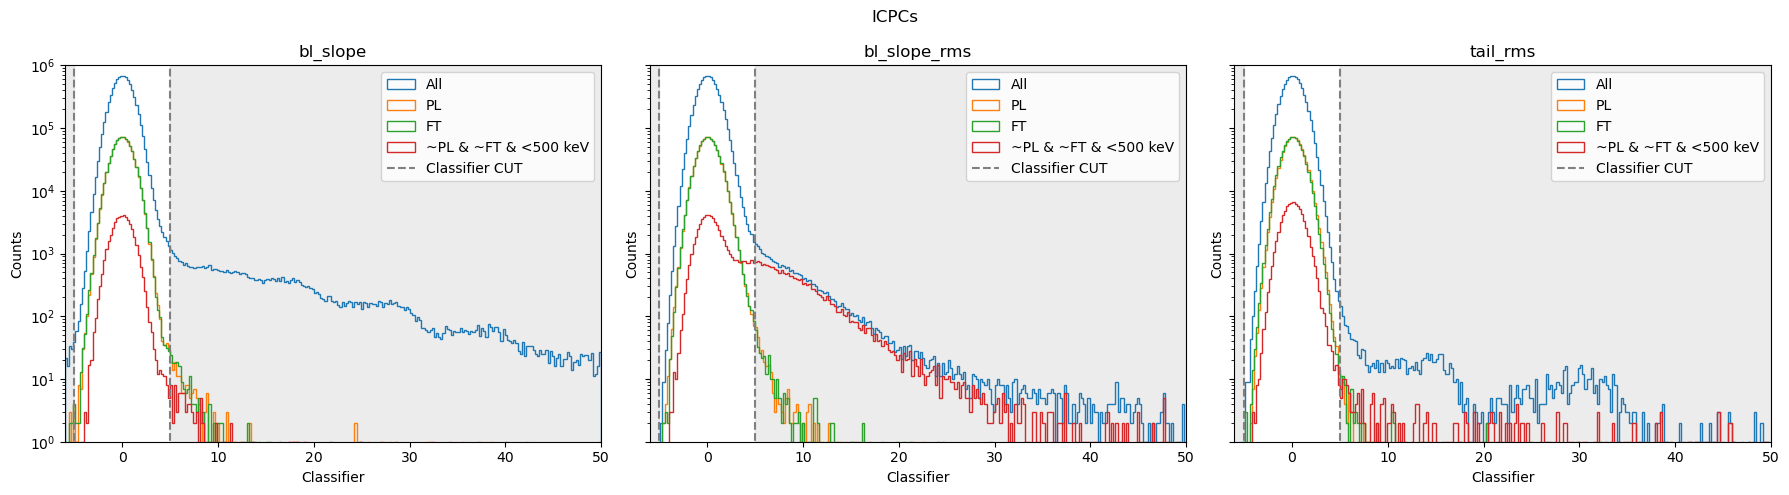

In [197]:
all_plots(data_ICPC, params, cmax =50, title = "ICPCs")

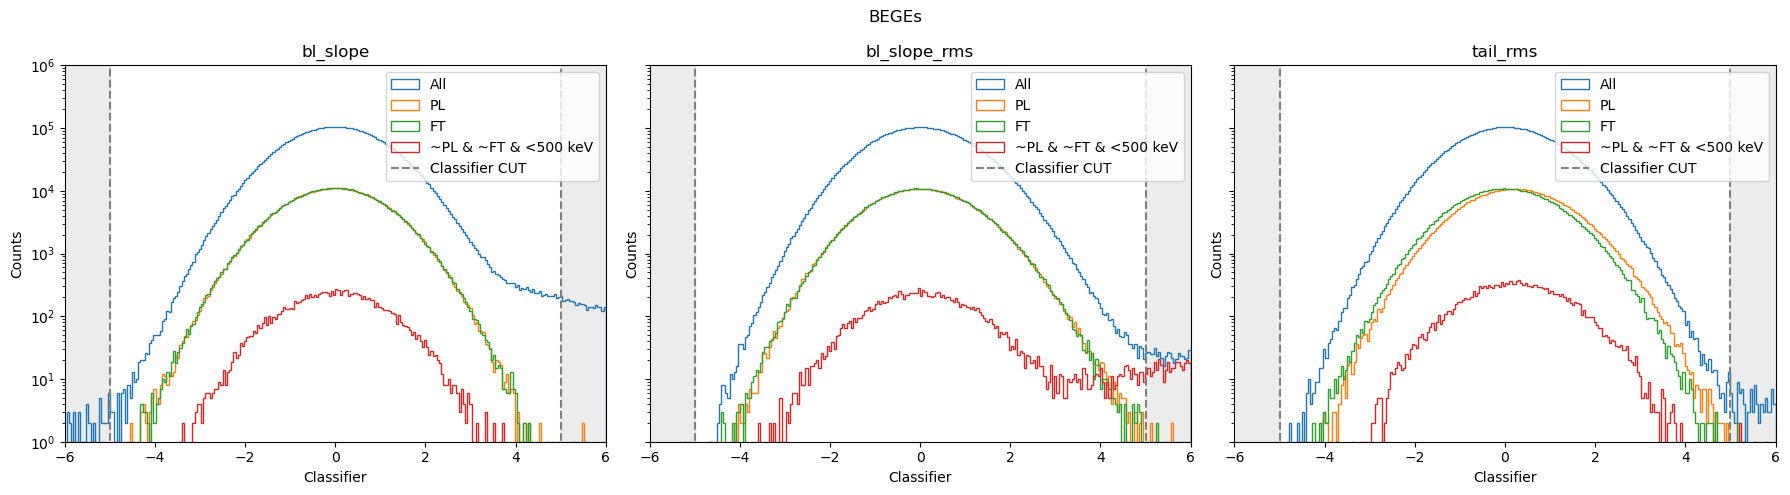

In [199]:
all_plots(data_BEGe, params, cmax =6, title = "BEGEs")

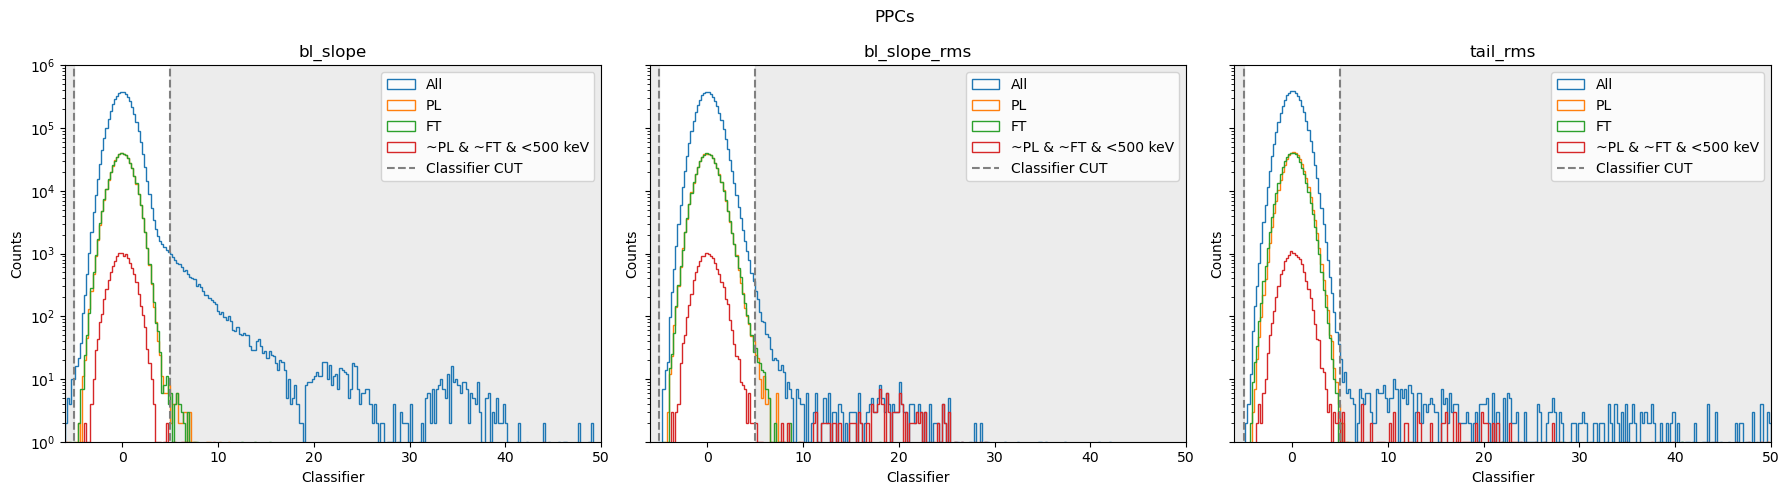

In [201]:
all_plots(data_PPC, params, cmax =50, title = "PPCs")

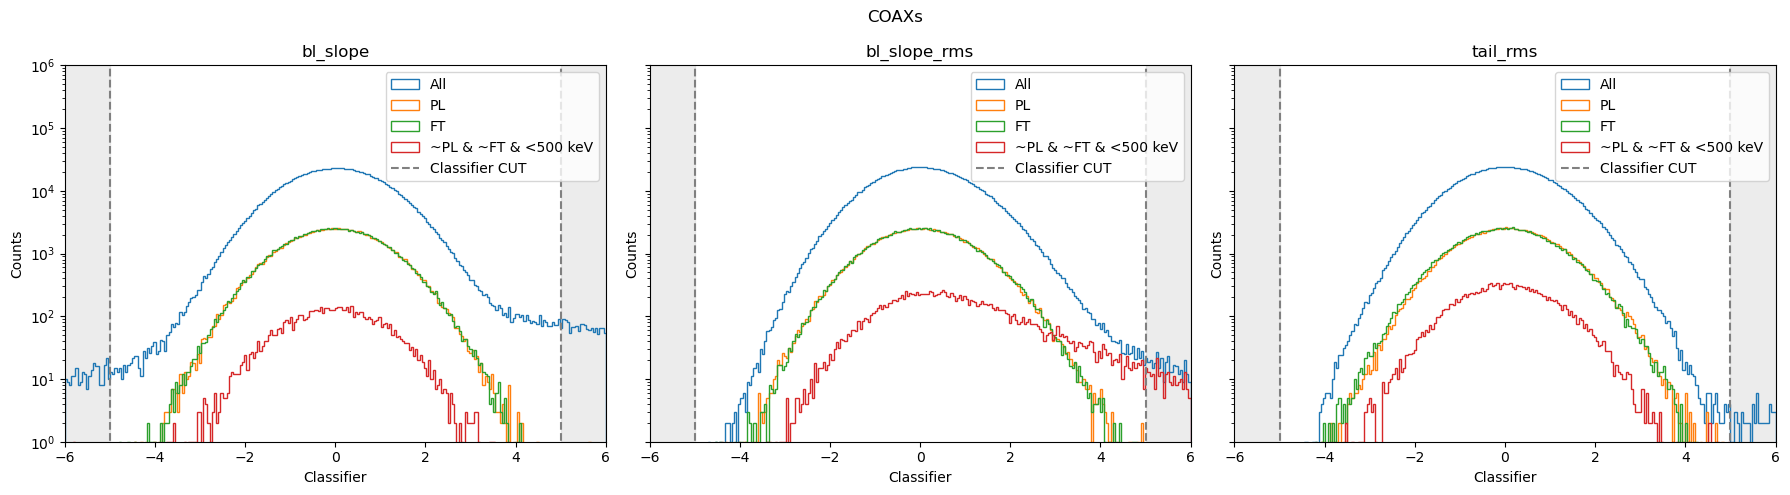

In [205]:
all_plots(data_COAX, params, cmax =6, title = "COAXs")

# SUM ALL DATA

In [212]:
data_COAX

,bl_slope,bl_slope_rms,cuspEmax,cuspEmax_ctc,cuspEmax_ctc_cal,is_valid_bl_slope,is_valid_bl_slope_rms,is_valid_cal,is_valid_tail,is_valid_tail_rms,...,tail_rms,forced_trigger,is_pulser,is_muon,is_HPGe,is_discharge,is_below_500keV,classifier_bl_slope,classifier_bl_slope_rms,classifier_tail_rms
0,0.001879,17.008125,433.479401,433.479401,185.007830,True,True,True,True,True,...,15.564026,False,False,False,True,False,True,0.050848,0.711705,-1.533264
1,0.016437,17.548412,5.507334,5.507334,1.983510,True,True,False,True,True,...,16.281841,False,False,False,True,False,False,0.489753,1.465559,-0.243217
2,0.018304,17.364841,11.372599,11.372599,4.491957,True,True,False,True,True,...,17.066465,False,False,False,True,False,False,0.546026,1.209425,1.166898
3,-0.015885,17.325434,1.284129,NaN,NaN,True,True,False,True,True,...,17.599028,False,False,False,True,False,False,-0.484704,1.154440,2.124011
4,0.028009,16.892708,3.430843,3.430843,1.095439,True,True,False,True,True,...,16.121349,True,False,False,False,False,False,0.838620,0.550664,-0.531651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1284271,0.052856,32.445068,14.362865,14.362865,2.184801,True,True,False,True,True,...,29.321697,False,False,False,True,False,False,1.032246,0.693910,-1.188062
1284272,0.044165,33.888062,6.066146,NaN,NaN,True,True,False,True,True,...,33.323509,False,False,False,True,False,False,0.859796,1.510460,1.633915
1284273,0.044341,29.290079,13.881230,NaN,NaN,True,True,False,True,True,...,33.172501,False,False,False,True,False,False,0.863277,-1.091411,1.527427
1284274,0.027145,29.929747,21.127783,21.127783,3.243950,True,True,False,True,True,...,29.774529,False,False,False,True,False,False,0.522058,-0.729440,-0.868736


In [207]:
data_ALL = pd.concat([data_COAX, data_PPC, data_ICPC, data_BEGe], ignore_index=True)

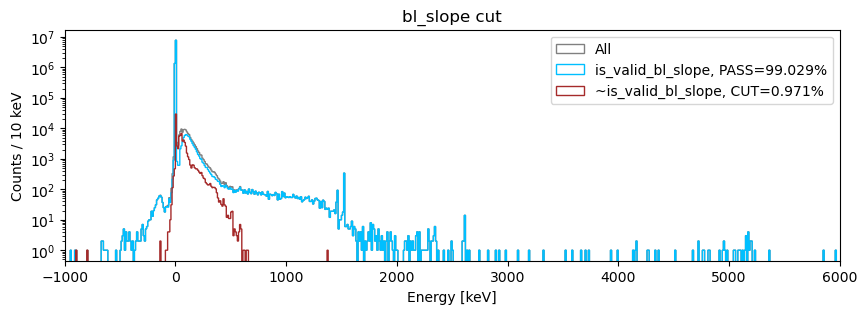

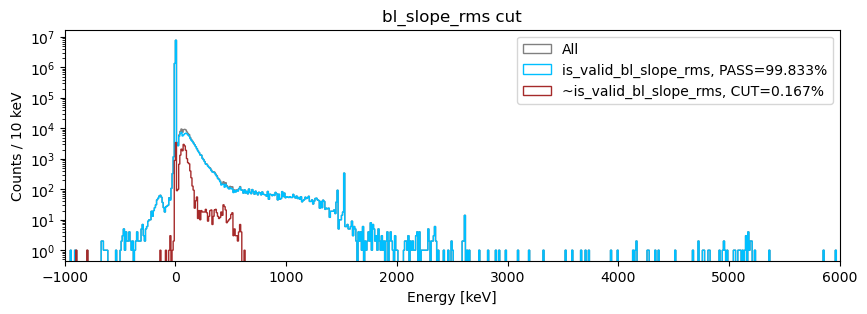

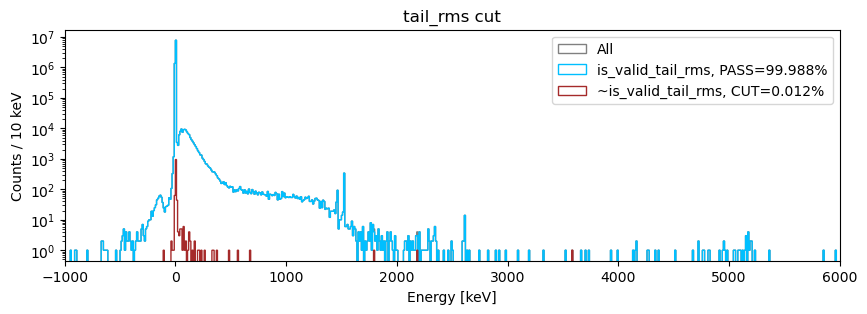

In [227]:
energy_spectrum_cut_plot(data_ALL, "bl_slope")
energy_spectrum_cut_plot(data_ALL, "bl_slope_rms")
energy_spectrum_cut_plot(data_ALL, "tail_rms")